# Initial Neighborhoods and Labelme Export

I adopted this from Aaron's scripts - https://github.com/Aaron5947/iGSCs_XeniumA480_Experiment_1/blob/main/02_Calculating_initial_neighborhood.ipynb

This notebook version was previously adapted by Aaron from `Alex_main_functions/Processing/02_Calculating_Initial_Neighborhoods.py`.

It takes the filtered AnnData objects from step 01, learns coarse spatial expression neighborhoods with NMF, assigns each cell an initial neighborhood/topic, and exports topic-colored images for Labelme bad-tissue annotation.

## Workflow

1. Load the filtered `.h5ad` files from step 01.
01_preprocessing reference also from Aaron's github 
2. Build low-resolution spatial expression bins across all samples.
3. Fit one shared NMF neighborhood model.
4. Assign every cell to its strongest local topic/neighborhood.
5. Save the annotated AnnData objects, neighborhood plots, and `topic_image.png` files for Labelme.
6. Annotate bad tissue in Labelme before running step 03.

In [3]:
from pathlib import Path
import sys
import textwrap

import matplotlib.pyplot as plt
from matplotlib.colors import to_hex, to_rgb
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw
import scanpy as sc
from scipy import sparse
from scipy.spatial import KDTree
from sklearn.decomposition import NMF
PROCESSING_DIR = Path("~/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/Aaron/Xenium-functions-from-Alex").expanduser()
if str(PROCESSING_DIR) not in sys.path:
    sys.path.insert(0, str(PROCESSING_DIR))
from core_functions.initial_neighborhoods import (
    create_grid_bins,
    plot_top_words,
)

/opt/anaconda3/envs/scvi_mac/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Parameters

The paths below match the filtered outputs produced by the current step-01 notebook. If you later switch to the scripted pipeline layout, point `SAMPLE_INPUTS` to each sample's `adatas/01_preprocessed.h5ad` instead.

In [4]:
BASE_DIR = Path("~/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627").expanduser()
INPUT_DIR = BASE_DIR / "01_Importing_QC"

SAMPLE_INPUTS = {
    "AD_inf": INPUT_DIR / "AD_inf_filtered.h5ad",
    "AD_mock": INPUT_DIR / "AD_mock_filtered.h5ad",
    "reference_ln": INPUT_DIR / "reference_ln_filtered.h5ad"
}

OUTPUT_ROOT = BASE_DIR / "02_Calculating_initial_neighborhood"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

OUTPUT_NAME = "02_initial_neighborhoods.h5ad"
NUM_NEIGHBORHOODS = 15
LOW_RES_BINNING = 200
N_NEIGHBORS = 10
TOPIC_IMAGE_DOWNSIZE = 10.0
TOPIC_IMAGE_POINT_SIZE = 1
TOP_GENES = 5
RANDOM_STATE = 0
MAX_ITER = 1000

In [5]:
DEFAULT_IRRELEVANT_FEATURES = [
    "tag_BFP",
    "tdTomato",
    "BFP",
    "mCherry_RFP",
    "mKO.1",
    "puromycin",
    "hygromycin",
    "P14_TCRa",
    "OT-I_TCRb",
    "Cd45.1",
    "Cd45.2",
    "GFP",
    "mCherry",
]

In [6]:
def validate_input_paths(sample_inputs):
    missing = {sample: path for sample, path in sample_inputs.items() if not Path(path).exists()}
    if missing:
        missing_text = "\n".join(f"- {sample}: {path}" for sample, path in missing.items())
        raise FileNotFoundError(f"Missing input h5ad files:\n{missing_text}")
    print(f"Found {len(sample_inputs)} filtered AnnData files.")

validate_input_paths(SAMPLE_INPUTS)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_ROOT

Found 3 filtered AnnData files.


PosixPath('/Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/02_Calculating_initial_neighborhood')

### Load filtered AnnData
Each object needs spatial coordinates. The helper uses `adata.obsm["X_spatial"]` if present, otherwise it creates that array from `obs[["x_centroid", "y_centroid"]]`.

In [7]:
def load_input_adata(h5ad_path):
    h5ad_path = Path(h5ad_path).expanduser().resolve()
    adata = sc.read_h5ad(h5ad_path)

    if "X_spatial" not in adata.obsm:
        if not {"x_centroid", "y_centroid"}.issubset(adata.obs.columns):
            raise ValueError(
                f"{h5ad_path} is missing X_spatial and x_centroid/y_centroid columns"
            )
        adata.obsm["X_spatial"] = adata.obs[["x_centroid", "y_centroid"]].to_numpy()

    return adata

In [8]:
adatas = {
    sample: load_input_adata(path)
    for sample, path in SAMPLE_INPUTS.items()
}

pd.DataFrame(
    [
        {
            "sample": sample,
            "cells": adata.n_obs,
            "features": adata.n_vars,
            "has_X_spatial": "X_spatial" in adata.obsm,
        }
        for sample, adata in adatas.items()
    ]
)

,sample,cells,features,has_X_spatial
0,AD_inf,57466,480,True
1,AD_mock,64594,480,True
2,reference_ln,45469,480,True


## Neighborhood Model Helpers

The shared NMF model is trained on coarse spatial bins pooled across all selected samples. Then the same model is transformed back onto per-cell nearest-neighbor expression neighborhoods.

In [9]:
def build_feature_names(adata, excluded_features):
    feature_mask = ~adata.var_names.isin(excluded_features)
    feature_names = adata.var_names[feature_mask].tolist()
    if not feature_names:
        raise ValueError("No features remain after excluding irrelevant features")
    return feature_names


def _feature_indices(adata, feature_names, sample_name="sample"):
    column_indices = adata.var_names.get_indexer(feature_names)
    if np.any(column_indices < 0):
        missing_features = np.array(feature_names)[column_indices < 0][:10].tolist()
        raise ValueError(f"{sample_name} is missing model features: {missing_features}")
    return column_indices


def build_binned_training_frame(adata, feature_names, low_res_binning, sample_name="sample"):
    spatial_points = np.asarray(adata.obsm["X_spatial"])
    binned_points, _ = create_grid_bins(spatial_points, low_res_binning)

    bin_assignments = np.zeros(adata.n_obs, dtype=int)
    bin_counts = np.zeros(low_res_binning * low_res_binning, dtype=int)
    bin_id = 0

    for row in binned_points:
        for cell_indices in row:
            if cell_indices:
                indices = np.asarray(cell_indices, dtype=int)
                bin_assignments[indices] = bin_id
                bin_counts[bin_id] = len(indices)
            bin_id += 1

    weights = np.zeros(adata.n_obs, dtype=np.float64)
    nonzero_mask = bin_counts[bin_assignments] > 0
    weights[nonzero_mask] = 1.0 / bin_counts[bin_assignments[nonzero_mask]]

    bin_matrix = sparse.csr_matrix(
        (weights, (bin_assignments, np.arange(adata.n_obs))),
        shape=(len(bin_counts), adata.n_obs),
    )

    column_indices = _feature_indices(adata, feature_names, sample_name=sample_name)
    X = bin_matrix @ adata.X[:, column_indices]
    if sparse.issparse(X):
        X = X.toarray()

    return pd.DataFrame(X, columns=feature_names)


def fit_shared_neighborhood_model(
    adatas,
    excluded_features,
    low_res_binning,
    num_neighborhoods,
    random_state,
    max_iter,
):
    first_adata = next(iter(adatas.values()))
    feature_names = build_feature_names(first_adata, excluded_features)
    training_frames = []

    for sample_name, adata in adatas.items():
        print(f"Building low-resolution bins for {sample_name}")
        training_frames.append(
            build_binned_training_frame(
                adata,
                feature_names,
                low_res_binning,
                sample_name=sample_name,
            )
        )

    training_matrix = pd.concat(training_frames, axis=0, ignore_index=True)
    model = NMF(
        n_components=num_neighborhoods,
        init="nndsvda",
        random_state=random_state,
        max_iter=max_iter,
    )
    model.fit(training_matrix.to_numpy(dtype=np.float64, copy=False))
    return model, feature_names, training_matrix

In [10]:
def sum_neighbor_expression(expression_matrix, neighbor_indices):
    if neighbor_indices.ndim == 1:
        neighbor_indices = neighbor_indices[:, np.newaxis]

    rows = np.repeat(np.arange(neighbor_indices.shape[0]), neighbor_indices.shape[1])
    cols = neighbor_indices.reshape(-1)
    weights = sparse.csr_matrix(
        (np.ones(len(rows), dtype=np.float32), (rows, cols)),
        shape=(neighbor_indices.shape[0], neighbor_indices.shape[0]),
    )
    return weights @ expression_matrix


def zscore_topics(topics_frame):
    centered = topics_frame - topics_frame.mean(axis=0)
    scale = topics_frame.std(axis=0, ddof=0).replace(0, 1)
    return centered / scale


def assign_topics_to_cells(adata, model, feature_names, n_neighbors, sample_name="sample"):
    spatial_points = np.asarray(adata.obsm["X_spatial"])
    tree = KDTree(spatial_points)
    _, neighbor_indices = tree.query(spatial_points, k=n_neighbors)

    neighborhood_expression = sum_neighbor_expression(adata.X, neighbor_indices)
    column_indices = _feature_indices(adata, feature_names, sample_name=sample_name)
    topic_input = neighborhood_expression[:, column_indices]

    if sparse.issparse(topic_input):
        topic_input = topic_input.tocsr().astype(model.components_.dtype)
    else:
        topic_input = np.asarray(topic_input, dtype=model.components_.dtype)

    topic_weights = model.transform(topic_input)
    topics_frame = pd.DataFrame(
        topic_weights,
        columns=[f"Topic {i + 1}" for i in range(topic_weights.shape[1])],
        index=adata.obs_names,
    )
    topics_frame = zscore_topics(topics_frame)

    adata = adata.copy()
    adata.obs = pd.concat([adata.obs, topics_frame], axis=1)
    adata.obs["topic"] = pd.Categorical(
        (np.argmax(topics_frame.to_numpy(), axis=1) + 1).astype(str)
    )
    return adata


## Fit Shared NMF Model

This is the heavy training step. With the default settings, it creates `200 x 200` spatial bins per sample and fits `15` neighborhoods.

In [11]:
model, feature_names, training_matrix = fit_shared_neighborhood_model(
    adatas,
    DEFAULT_IRRELEVANT_FEATURES,
    LOW_RES_BINNING,
    NUM_NEIGHBORHOODS,
    RANDOM_STATE,
    MAX_ITER,
)

training_matrix.shape

Building low-resolution bins for AD_inf


100%|██████████| 57466/57466 [00:00<00:00, 243807.82it/s]


Building low-resolution bins for AD_mock


100%|██████████| 64594/64594 [00:00<00:00, 253118.23it/s]


Building low-resolution bins for reference_ln


100%|██████████| 45469/45469 [00:00<00:00, 244165.47it/s]


(120000, 480)

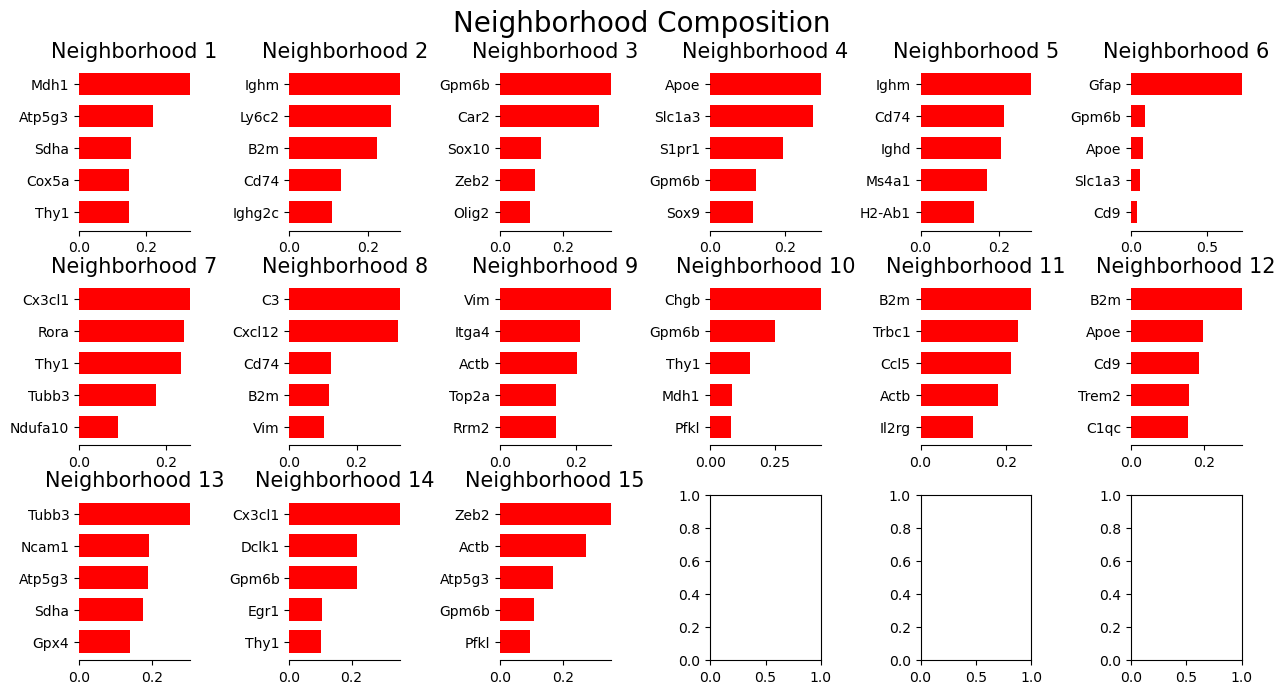

In [12]:
plot_top_words(
    model,
    feature_names,
    TOP_GENES,
    "Neighborhood Composition",
    show=True,
)


## Output Helpers

These functions save summary plots, export the Labelme topic image, and record the image transform metadata needed by step 03.

In [13]:
def sample_output_dir(sample_name):
    return OUTPUT_ROOT / sample_name


def assign_topic_colors(adata):
    categories = adata.obs["topic"].cat.categories
    cmap = plt.get_cmap("tab20", len(categories))
    adata.uns["topic_colors"] = [
        to_hex(cmap(i), keep_alpha=False)
        for i in range(len(categories))
    ]
    return adata


def save_topic_spatial_plot(adata, output_dir):
    neighborhood_dir = Path(output_dir) / "figures" / "neighborhoods"
    neighborhood_dir.mkdir(parents=True, exist_ok=True)
    plot_path = neighborhood_dir / "initial_topic_spatial.png"

    sc.pl.embedding(
        adata,
        basis="spatial",
        color="topic",
        palette=adata.uns["topic_colors"],
        title="Initial neighborhood",
        size=2,
        show=False,
    )
    plt.gcf().savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.close(plt.gcf())
    return plot_path


def save_neighborhood_composition_plot(model, feature_names, output_dir, top_genes):
    neighborhood_dir = Path(output_dir) / "figures" / "neighborhoods"
    neighborhood_dir.mkdir(parents=True, exist_ok=True)
    plot_path = neighborhood_dir / "neighborhood_composition.png"

    plot_top_words(
        model,
        feature_names,
        top_genes,
        "Neighborhood Composition",
        save_path=plot_path,
        show=False,
    )
    return plot_path


In [14]:
def export_topic_image(adata, output_dir, downsize, point_size):
    filtering_dir = Path(output_dir) / "filtering"
    filtering_dir.mkdir(parents=True, exist_ok=True)

    spatial_points = np.asarray(adata.obsm["X_spatial"], dtype=float)
    min_xy = spatial_points.min(axis=0)
    scaled_points = (spatial_points - min_xy) / downsize

    padding = max(5, point_size + 2)
    scaled_points = scaled_points + padding
    max_xy = np.ceil(scaled_points.max(axis=0)).astype(int)
    image_width = int(max_xy[0] + padding + 1)
    image_height = int(max_xy[1] + padding + 1)

    topic_categories = adata.obs["topic"].cat.categories
    topic_color_lookup = {
        category: tuple(int(channel * 255) for channel in to_rgb(adata.uns["topic_colors"][i]))
        for i, category in enumerate(topic_categories)
    }
    image_colors = [
        topic_color_lookup[topic]
        for topic in adata.obs["topic"].astype(str).tolist()
    ]

    base_image = Image.new("RGB", (image_width, image_height), (255, 255, 255))
    draw = ImageDraw.Draw(base_image)
    for point, color in zip(scaled_points, image_colors):
        x, y = point
        draw.ellipse(
            (x - point_size, y - point_size, x + point_size, y + point_size),
            fill=color,
        )

    image_path = filtering_dir / "topic_image.png"
    base_image.save(image_path)

    adata.uns["filtering_downsize"] = float(downsize)
    adata.uns["filtering_image_origin"] = min_xy.tolist()
    adata.uns["filtering_image_padding"] = int(padding)
    adata.uns["filtering_image_size"] = [image_width, image_height]
    adata.uns["filtering_topic_image_path"] = str(image_path)
    adata.uns["filtering_topic_annotation_json"] = str(image_path.with_suffix(".json"))
    return adata, image_path

In [15]:
def build_labelme_instruction_text(image_paths):
    lines = [
        "Labelme annotation is required before the next processing step.",
        "",
        "1. Launch Labelme.",
        "2. Open each topic image listed below.",
        "3. Draw polygons around the tissue regions that should be removed.",
        "4. Press Enter to finish each polygon.",
        "5. Set the label to `remove`.",
        "6. Save the annotation as a JSON file with the same basename as the image.",
        "",
        "Images to annotate:",
    ]

    for image_path in image_paths:
        image_path = Path(image_path)
        json_path = image_path.with_suffix(".json")
        lines.append(f"- Image: {image_path}")
        lines.append(f"  Save JSON as: {json_path}")

    return "\n".join(lines)


def write_labelme_instruction_file(output_dir, instruction_text):
    instruction_path = Path(output_dir) / "filtering" / "labelme_instructions.txt"
    instruction_path.parent.mkdir(parents=True, exist_ok=True)
    instruction_path.write_text(instruction_text)
    return instruction_path


## Assign Initial Neighborhoods and Save Outputs

This processes each sample independently after fitting the shared model. The output structure is:

- `02_Calculating_initial_neighborhood/<sample>/adatas/02_initial_neighborhoods.h5ad`
- `02_Calculating_initial_neighborhood/<sample>/figures/neighborhoods/initial_topic_spatial.png`
- `02_Calculating_initial_neighborhood/<sample>/figures/neighborhoods/neighborhood_composition.png`
- `02_Calculating_initial_neighborhood/<sample>/filtering/topic_image.png`


In [16]:
def process_sample(sample_name, adata, model, feature_names):
    print(f"Processing {sample_name}")
    output_dir = sample_output_dir(sample_name)
    adata_dir = output_dir / "adatas"
    adata_dir.mkdir(parents=True, exist_ok=True)

    adata = assign_topics_to_cells(
        adata,
        model,
        feature_names,
        N_NEIGHBORS,
        sample_name=sample_name,
    )
    adata = assign_topic_colors(adata)

    composition_plot_path = save_neighborhood_composition_plot(
        model,
        feature_names,
        output_dir,
        TOP_GENES,
    )
    spatial_plot_path = save_topic_spatial_plot(adata, output_dir)
    adata, topic_image_path = export_topic_image(
        adata,
        output_dir,
        TOPIC_IMAGE_DOWNSIZE,
        TOPIC_IMAGE_POINT_SIZE,
    )

    adata.uns["initial_neighborhood_input_path"] = str(SAMPLE_INPUTS[sample_name])
    adata.uns["initial_neighborhood_output_path"] = str(adata_dir / OUTPUT_NAME)
    adata.uns["initial_neighborhood_parameters"] = {
        "num_neighborhoods": int(NUM_NEIGHBORHOODS),
        "low_res_binning": int(LOW_RES_BINNING),
        "n_neighbors": int(N_NEIGHBORS),
        "topic_image_downsize": float(TOPIC_IMAGE_DOWNSIZE),
        "topic_image_point_size": int(TOPIC_IMAGE_POINT_SIZE),
        "random_state": int(RANDOM_STATE),
        "max_iter": int(MAX_ITER),
    }

    output_path = adata_dir / OUTPUT_NAME
    adata.write_h5ad(output_path)
    print(f"Wrote {output_path}")

    return {
        "sample": sample_name,
        "output_dir": output_dir,
        "adata_path": output_path,
        "composition_plot_path": composition_plot_path,
        "spatial_plot_path": spatial_plot_path,
        "topic_image_path": topic_image_path,
        "adata": adata,
    }

In [17]:
outputs = {
    sample_name: process_sample(sample_name, adata, model, feature_names)
    for sample_name, adata in adatas.items()
}

instruction_text = build_labelme_instruction_text(
    [output["topic_image_path"] for output in outputs.values()]
)

for output in outputs.values():
    write_labelme_instruction_file(output["output_dir"], instruction_text)

print("=" * 80)
print(textwrap.dedent(instruction_text))
print("=" * 80)

Processing AD_inf
Wrote /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/02_Calculating_initial_neighborhood/AD_inf/adatas/02_initial_neighborhoods.h5ad
Processing AD_mock
Wrote /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/02_Calculating_initial_neighborhood/AD_mock/adatas/02_initial_neighborhoods.h5ad
Processing reference_ln
Wrote /Users/valishashah/Library/CloudStorage/Box-Box/Kaech Lab Folder/Valisha/AD Serial Infection Project  (Irene & Brian W)/Spatial Transcriptomics 20260518/RESULTS/20240627__192310__KAECH_AD_GBM_240627/02_Calculating_initial_neighborhood/reference_ln/adatas/02_initial_neighborhoods.h5ad
Labelme annotation is required before the next processing step.

1. Launch La

## Quick Checks

Use these cells after processing to inspect the saved outputs and topic counts.

In [18]:
summary_rows = []
for sample_name, output in outputs.items():
    adata = output["adata"]
    summary_rows.append(
        {
            "sample": sample_name,
            "cells": adata.n_obs,
            "topics_detected": adata.obs["topic"].nunique(),
            "adata_path": output["adata_path"],
            "topic_image_path": output["topic_image_path"],
        }
    )

pd.DataFrame(summary_rows)

,sample,cells,topics_detected,adata_path,topic_image_path
0,AD_inf,57466,15,/Users/valishashah/Library/CloudStorage/Box-Bo...,/Users/valishashah/Library/CloudStorage/Box-Bo...
1,AD_mock,64594,15,/Users/valishashah/Library/CloudStorage/Box-Bo...,/Users/valishashah/Library/CloudStorage/Box-Bo...
2,reference_ln,45469,15,/Users/valishashah/Library/CloudStorage/Box-Bo...,/Users/valishashah/Library/CloudStorage/Box-Bo...


In [19]:
# Optional: preview one sample's topic counts.
preview_sample = next(iter(outputs))
outputs[preview_sample]["adata"].obs["topic"].value_counts().sort_index()

topic
1     1953
10    1755
11    3776
12    3384
13    6302
14    6315
15    2450
2     2431
3     8105
4     3806
5     3075
6     3987
7     4312
8     3682
9     2133
Name: count, dtype: int64

## Next Step

Open each `topic_image.png` in Labelme, draw polygons around regions to remove, and save each JSON next to the image as `topic_image.json`. After that, run the step-03 bad-tissue removal notebook or script.